In [165]:


!pip install -q faster-whisper
!pip install -q librosa
!pip install -q spacy
!pip install -q scikit-learn
!pip install -q pandas
!pip install -q numpy
!pip install -q matplotlib
!pip install -q seaborn
!pip install -q tqdm


!python -m spacy download en_core_web_sm -q

print("All required packages installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 90.5 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All required packages installed successfully!


# Grammar Scoring Engine for Spoken Data

## Objective

The objective is to predict a continuous grammar score between 0 and 5
from spoken English recordings.

The dataset contains audio recordings together with human-provided
Mean Opinion Scores (MOS) representing grammatical quality.

## Approach

We investigate both textual and acoustic characteristics of speech.

The pipeline consists of:

1. Audio preprocessing
2. Speech-to-text transcription using Whisper
3. Text-based linguistic feature extraction
4. Acoustic feature extraction
5. Feature combination
6. Ridge Regression
7. Cross-validation and hyperparameter tuning
8. Final prediction and submission

In [166]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import spacy

from collections import Counter

from faster_whisper import WhisperModel

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

In [167]:
RANDOM_STATE = 42

TRAIN_AUDIO_DIR = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train"
TEST_AUDIO_DIR = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test"

TRANSCRIPT_PATH = "/kaggle/working/train_transcripts.csv"
TEST_TRANSCRIPT_PATH = "/kaggle/working/test_transcripts.csv"

LINGUISTIC_FEATURE_PATH = "/kaggle/working/linguistic_features.csv"
AUDIO_FEATURE_PATH = "/kaggle/working/audio_features.csv"

print("Configuration loaded.")
print("Training audio:", TRAIN_AUDIO_DIR)
print("Test audio:", TEST_AUDIO_DIR)

Configuration loaded.
Training audio: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train
Test audio: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test


In [168]:
train = pd.read_csv(
    "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train.csv"
)

test = pd.read_csv(
    "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test.csv"
)

sample_submission = pd.read_csv(
    "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/sample_submission.csv"
)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

display(train.head())
display(test.head())
display(sample_submission.head())

Train shape: (769, 2)
Test shape: (216, 2)
Sample submission shape: (204, 2)


,filename,label
0,audio_192.wav,3.0
1,audio_436.wav,3.0
2,audio_447.wav,3.5
3,audio_126.wav,2.0
4,audio_61.wav,2.0


,filename,label
0,audio_128.wav,-1
1,audio_156.wav,-1
2,audio_19.wav,-1
3,audio_108.wav,-1
4,audio_206.wav,-1


,filename,label
0,audio_804.wav,-1
1,audio_1028.wav,-1
2,audio_865.wav,-1
3,audio_774.wav,-1
4,audio_1138.wav,-1


In [169]:
print("Training samples:", len(train))
print("Test samples:", len(test))

print("\nTraining columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nMissing training values:")
print(train.isna().sum())

print("\nLabel distribution:")
display(train["label"].describe())

Training samples: 769
Test samples: 216

Training columns:
['filename', 'label']

Test columns:
['filename', 'label']

Missing training values:
filename    0
label       0
dtype: int64

Label distribution:


count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64

In [170]:
missing_train = []

for filename in train["filename"]:
    path = os.path.join(
        TRAIN_AUDIO_DIR,
        filename
    )

    if not os.path.exists(path):
        missing_train.append(filename)

print(
    "Missing training audio files:",
    len(missing_train)
)

if missing_train:
    print(missing_train[:20])

Missing training audio files: 0


In [171]:
missing_test = []

for filename in test["filename"]:
    path = os.path.join(
        TEST_AUDIO_DIR,
        filename
    )

    if not os.path.exists(path):
        missing_test.append(filename)

print(
    "Missing test audio files:",
    len(missing_test)
)

if missing_test:
    print(missing_test[:20])

Missing test audio files: 0


In [172]:
durations = []

for filename in train["filename"]:

    path = os.path.join(
        TRAIN_AUDIO_DIR,
        filename
    )

    try:
        duration = librosa.get_duration(
            path=path
        )

        durations.append(duration)

    except Exception:
        durations.append(np.nan)

train["duration"] = durations

print(train["duration"].describe())

count    769.000000
mean      55.781067
std        7.908964
min       20.060000
25%       54.186687
50%       60.074688
75%       60.074688
max       61.040000
Name: duration, dtype: float64


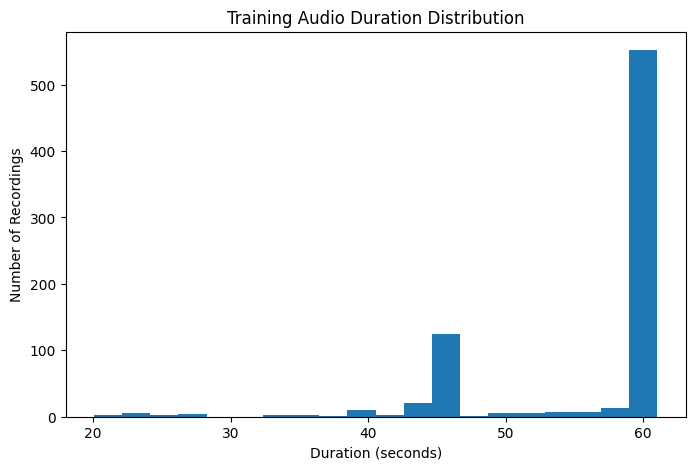

In [173]:
plt.figure(figsize=(8, 5))

plt.hist(
    train["duration"].dropna(),
    bins=20
)

plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Recordings")
plt.title("Training Audio Duration Distribution")

plt.show()

In [174]:
whisper_model = WhisperModel(
    "small",
    device="cuda",
    compute_type="float16"
)

print("Whisper model loaded successfully.")

Whisper model loaded successfully.


## Speech-to-Text Transcription

The audio recordings are converted into English transcripts using
the Whisper speech recognition model.

The transcripts allow us to extract textual and linguistic
information related to grammar quality.

A checkpoint file is used so that transcription does not need to
restart from the beginning if the notebook session is interrupted.

In [175]:
if os.path.exists(TRANSCRIPT_PATH):

    transcript_df = pd.read_csv(
        TRANSCRIPT_PATH
    )

    print("Existing transcript checkpoint found.")
    print(
        "Already processed:",
        len(transcript_df)
    )

else:

    transcript_df = pd.DataFrame(
        columns=[
            "filename",
            "label",
            "transcript"
        ]
    )

    print("Starting transcription from scratch.")

Existing transcript checkpoint found.
Already processed: 769


In [176]:
processed_files = set(
    transcript_df["filename"].astype(str)
)

remaining = train[
    ~train["filename"].astype(str).isin(
        processed_files
    )
].copy()

print("Total training files:", len(train))
print("Already processed:", len(processed_files))
print("Remaining:", len(remaining))

Total training files: 769
Already processed: 769
Remaining: 0


In [177]:
for i, (_, row) in enumerate(
    remaining.iterrows(),
    start=1
):

    filename = row["filename"]
    label = row["label"]

    audio_path = os.path.join(
        TRAIN_AUDIO_DIR,
        filename
    )

    try:

        audio, sr = librosa.load(
            audio_path,
            sr=16000
        )

        segments, info = whisper_model.transcribe(
            audio,
            language="en"
        )

        transcript = " ".join(
            segment.text.strip()
            for segment in segments
        )

        new_row = pd.DataFrame([{
            "filename": filename,
            "label": label,
            "transcript": transcript
        }])

        transcript_df = pd.concat(
            [
                transcript_df,
                new_row
            ],
            ignore_index=True
        )

        if i % 10 == 0:

            transcript_df.to_csv(
                TRANSCRIPT_PATH,
                index=False
            )

            print(
                f"Processed {i}/{len(remaining)} "
                f"| Total saved: {len(transcript_df)}"
            )

    except Exception as e:

        print(
            f"ERROR processing {filename}: {e}"
        )


transcript_df.to_csv(
    TRANSCRIPT_PATH,
    index=False
)

print("Training transcription complete.")
print(
    "Total transcripts:",
    len(transcript_df)
)

Training transcription complete.
Total transcripts: 769


In [178]:
print(transcript_df.shape)

display(
    transcript_df.head(10)
)

print(
    "\nMissing transcripts:",
    transcript_df["transcript"].isna().sum()
)

print(
    "Empty transcripts:",
    (
        transcript_df["transcript"]
        .fillna("")
        .str.strip()
        .eq("")
        .sum()
    )
)

(769, 3)


,filename,label,transcript
0,audio_192.wav,3.0,"Well, the playground is very, very beautiful a..."
1,audio_436.wav,3.0,"The scene of a school playground, our playgrou..."
2,audio_447.wav,3.5,My favorite place to visit is the beach. I lov...
3,audio_126.wav,2.0,"Once upon a time, we, with five friends, went ..."
4,audio_61.wav,2.0,"Well, when I was a child, I remember I went to..."
5,audio_639.wav,2.5,The best thing of my life was probably when I ...
6,audio_703.wav,2.0,How many of you know several? No. The first da...
7,audio_509.wav,3.0,"smoothing effect. Besides this, I also have ho..."
8,audio_672.wav,4.0,The school playground is very big and is very ...
9,audio_344.wav,4.0,My number one goal in life is to become the be...



Missing transcripts: 0
Empty transcripts: 0


In [179]:
transcript_df["word_count"] = (
    transcript_df["transcript"]
    .str.split()
    .str.len()
)

print(
    transcript_df["word_count"].describe()
)

count    769.000000
mean      99.198960
std       27.152313
min        3.000000
25%       80.000000
50%      100.000000
75%      119.000000
max      166.000000
Name: word_count, dtype: float64


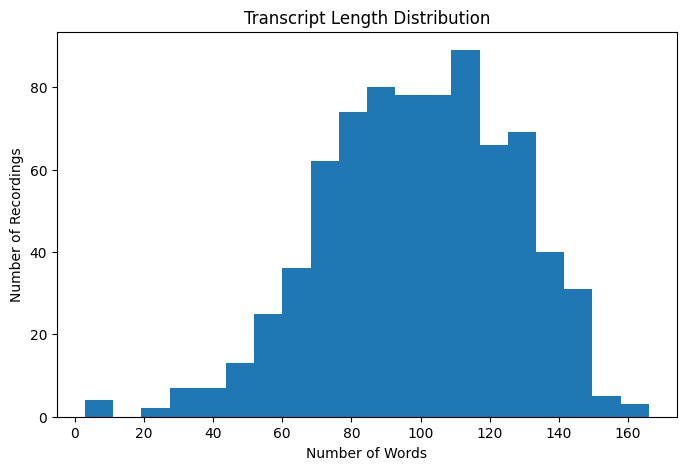

In [180]:
plt.figure(figsize=(8, 5))

plt.hist(
    transcript_df["word_count"],
    bins=20
)

plt.xlabel("Number of Words")
plt.ylabel("Number of Recordings")
plt.title("Transcript Length Distribution")

plt.show()

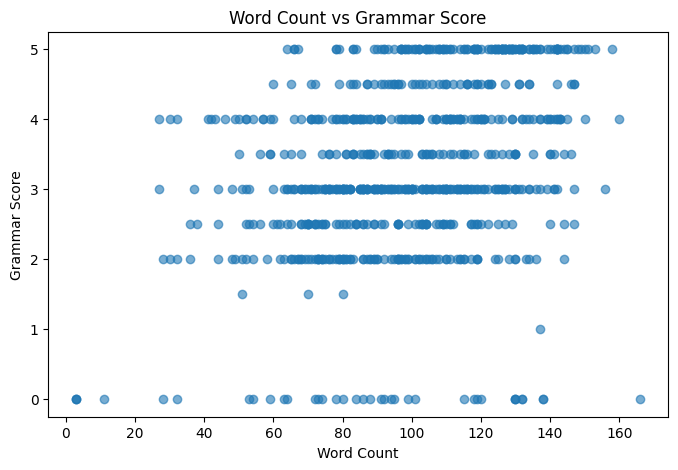

In [181]:
plt.figure(figsize=(8, 5))

plt.scatter(
    transcript_df["word_count"],
    transcript_df["label"],
    alpha=0.6
)

plt.xlabel("Word Count")
plt.ylabel("Grammar Score")
plt.title("Word Count vs Grammar Score")

plt.show()

In [182]:
X_train, X_val, y_train, y_val = train_test_split(
    transcript_df["transcript"],
    transcript_df["label"],
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 615
Validation samples: 154


## Baseline Model

The baseline predicts the mean grammar score of the training set
for every validation sample.

A useful machine learning model should achieve a lower RMSE than
this baseline.

In [183]:
mean_score = y_train.mean()

baseline_predictions = np.full(
    len(y_val),
    mean_score
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        baseline_predictions
    )
)

print(
    "Baseline RMSE:",
    baseline_rmse
)

Baseline RMSE: 1.3596105941011667


## TF-IDF + Ridge Regression

TF-IDF converts the transcripts into numerical representations
based on word and two-word phrase importance.

Ridge Regression is then used to predict the continuous grammar score.

In [184]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_val_tfidf = tfidf.transform(
    X_val
)

print(
    "Training TF-IDF shape:",
    X_train_tfidf.shape
)

print(
    "Validation TF-IDF shape:",
    X_val_tfidf.shape
)

Training TF-IDF shape: (615, 8353)
Validation TF-IDF shape: (154, 8353)


In [185]:
ridge_model = Ridge(
    alpha=10
)

ridge_model.fit(
    X_train_tfidf,
    y_train
)

tfidf_predictions = ridge_model.predict(
    X_val_tfidf
)

tfidf_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        tfidf_predictions
    )
)

print(
    "TF-IDF + Ridge RMSE:",
    tfidf_rmse
)

TF-IDF + Ridge RMSE: 1.2921964382023186


In [186]:
def extract_basic_features(text):

    text = str(text)

    words = text.split()

    sentences = re.split(
        r'[.!?]+',
        text
    )

    sentences = [
        s.strip()
        for s in sentences
        if s.strip()
    ]

    unique_words = set(
        word.lower().strip(
            ".,!?;:"
        )
        for word in words
    )

    word_count = len(words)

    sentence_count = len(
        sentences
    )

    avg_sentence_length = (
        word_count / sentence_count
        if sentence_count > 0
        else 0
    )

    vocabulary_richness = (
        len(unique_words) / word_count
        if word_count > 0
        else 0
    )

    return {
        "word_count": word_count,
        "sentence_count": sentence_count,
        "avg_sentence_length": avg_sentence_length,
        "unique_words": len(unique_words),
        "vocabulary_richness": vocabulary_richness
    }

In [187]:
feature_rows = transcript_df["transcript"].apply(
    extract_basic_features
)

basic_features = pd.DataFrame(
    feature_rows.tolist(),
    index=transcript_df.index
)

display(
    basic_features.head()
)

,word_count,sentence_count,avg_sentence_length,unique_words,vocabulary_richness
0,96,6,16.000000,58,0.604167
1,114,5,22.800000,53,0.464912
2,146,12,12.166667,76,0.520548
3,97,2,48.500000,42,0.432990
4,76,4,19.000000,45,0.592105


In [188]:
grammar_train = basic_features.loc[
    X_train.index
]

grammar_val = basic_features.loc[
    X_val.index
]

grammar_scaler = StandardScaler()

grammar_train_scaled = grammar_scaler.fit_transform(
    grammar_train
)

grammar_val_scaled = grammar_scaler.transform(
    grammar_val
)

In [189]:
X_train_grammar = hstack([
    X_train_tfidf,
    csr_matrix(grammar_train_scaled)
])

X_val_grammar = hstack([
    X_val_tfidf,
    csr_matrix(grammar_val_scaled)
])

grammar_model = Ridge(
    alpha=10
)

grammar_model.fit(
    X_train_grammar,
    y_train
)

grammar_predictions = grammar_model.predict(
    X_val_grammar
)

grammar_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        grammar_predictions
    )
)

print(
    "TF-IDF + Grammar Features RMSE:",
    grammar_rmse
)

TF-IDF + Grammar Features RMSE: 1.133007859112661


In [190]:
nlp = spacy.load(
    "en_core_web_sm"
)

print("spaCy model loaded.")

spaCy model loaded.


In [191]:
POS_TAGS = [
    "NOUN",
    "VERB",
    "ADJ",
    "ADV",
    "PRON",
    "ADP",
    "DET",
    "CONJ",
    "CCONJ",
    "SCONJ",
    "AUX",
    "NUM",
    "PART"
]


def extract_linguistic_features(text):

    doc = nlp(str(text))

    words = [
        token
        for token in doc
        if token.is_alpha
    ]

    total_words = len(words)

    if total_words == 0:
        total_words = 1

    features = {}

    pos_counts = Counter(
        token.pos_
        for token in words
    )

    for pos in POS_TAGS:

        features[
            f"{pos.lower()}_ratio"
        ] = (
            pos_counts[pos]
            / total_words
        )

    features["unique_pos_count"] = len(
        set(
            token.pos_
            for token in words
        )
    )

    features["avg_word_length"] = (
        np.mean([
            len(token.text)
            for token in words
        ])
        if words
        else 0
    )

    features["comma_count"] = sum(
        token.text == ","
        for token in doc
    )

    features["period_count"] = sum(
        token.text == "."
        for token in doc
    )

    features["question_count"] = sum(
        token.text == "?"
        for token in doc
    )

    features["exclamation_count"] = sum(
        token.text == "!"
        for token in doc
    )

    return features

In [192]:
linguistic_features = []

for i, text in enumerate(
    transcript_df["transcript"]
):

    linguistic_features.append(
        extract_linguistic_features(text)
    )

    if (i + 1) % 100 == 0:
        print(
            f"Processed {i + 1}/"
            f"{len(transcript_df)}"
        )

linguistic_features = pd.DataFrame(
    linguistic_features,
    index=transcript_df.index
)

print(
    "Linguistic feature matrix:",
    linguistic_features.shape
)

Processed 100/769
Processed 200/769
Processed 300/769
Processed 400/769
Processed 500/769
Processed 600/769
Processed 700/769
Linguistic feature matrix: (769, 19)


In [193]:
ling_train = linguistic_features.loc[
    X_train.index
]

ling_val = linguistic_features.loc[
    X_val.index
]

ling_scaler = StandardScaler()

ling_train_scaled = ling_scaler.fit_transform(
    ling_train
)

ling_val_scaled = ling_scaler.transform(
    ling_val
)

In [194]:
X_train_text_full = hstack([
    X_train_tfidf,
    csr_matrix(grammar_train_scaled),
    csr_matrix(ling_train_scaled)
])

X_val_text_full = hstack([
    X_val_tfidf,
    csr_matrix(grammar_val_scaled),
    csr_matrix(ling_val_scaled)
])

text_model = Ridge(
    alpha=10
)

text_model.fit(
    X_train_text_full,
    y_train
)

text_predictions = text_model.predict(
    X_val_text_full
)

text_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        text_predictions
    )
)

print(
    "TF-IDF + Grammar + Linguistic RMSE:",
    text_rmse
)

TF-IDF + Grammar + Linguistic RMSE: 1.0798781301579394


In [195]:
def extract_audio_features(audio_path):

    audio, sr = librosa.load(
        audio_path,
        sr=16000
    )

    features = {}

    features["duration"] = (
        len(audio) / sr
    )

    rms = librosa.feature.rms(
        y=audio
    )[0]

    features["rms_mean"] = np.mean(rms)
    features["rms_std"] = np.std(rms)

    zcr = librosa.feature.zero_crossing_rate(
        audio
    )[0]

    features["zcr_mean"] = np.mean(zcr)
    features["zcr_std"] = np.std(zcr)

    centroid = librosa.feature.spectral_centroid(
        y=audio,
        sr=sr
    )[0]

    features[
        "spectral_centroid_mean"
    ] = np.mean(centroid)

    features[
        "spectral_centroid_std"
    ] = np.std(centroid)

    bandwidth = librosa.feature.spectral_bandwidth(
        y=audio,
        sr=sr
    )[0]

    features[
        "spectral_bandwidth_mean"
    ] = np.mean(bandwidth)

    features[
        "spectral_bandwidth_std"
    ] = np.std(bandwidth)

    contrast = librosa.feature.spectral_contrast(
        y=audio,
        sr=sr
    )

    features[
        "spectral_contrast_mean"
    ] = np.mean(contrast)

    features[
        "spectral_contrast_std"
    ] = np.std(contrast)

    return features

In [196]:
if os.path.exists(AUDIO_FEATURE_PATH):

    audio_features = pd.read_csv(
        AUDIO_FEATURE_PATH
    )

    print("Existing audio features loaded.")

else:

    audio_features_list = []

    for i, filename in enumerate(
        train["filename"]
    ):

        audio_path = os.path.join(
            TRAIN_AUDIO_DIR,
            filename
        )

        try:

            features = extract_audio_features(
                audio_path
            )

            audio_features_list.append(
                features
            )

        except Exception as e:

            print(
                f"Error processing {filename}: {e}"
            )

            audio_features_list.append({})

        if (i + 1) % 50 == 0:

            print(
                f"Processed {i + 1}/"
                f"{len(train)}"
            )

    audio_features = pd.DataFrame(
        audio_features_list,
        index=transcript_df.index
    )

    audio_features.to_csv(
        AUDIO_FEATURE_PATH,
        index=False
    )

print(
    "Audio feature matrix:",
    audio_features.shape
)

Existing audio features loaded.
Audio feature matrix: (769, 11)


In [197]:
audio_train = audio_features.loc[
    X_train.index
]

audio_val = audio_features.loc[
    X_val.index
]

audio_scaler = StandardScaler()

audio_train_scaled = audio_scaler.fit_transform(
    audio_train
)

audio_val_scaled = audio_scaler.transform(
    audio_val
)

audio_model = Ridge(
    alpha=10
)

audio_model.fit(
    audio_train_scaled,
    y_train
)

audio_predictions = audio_model.predict(
    audio_val_scaled
)

audio_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        audio_predictions
    )
)

print(
    "Audio-only Ridge RMSE:",
    audio_rmse
)

Audio-only Ridge RMSE: 0.8760762558379847


In [198]:
combined_train_features = hstack([
    X_train_tfidf,
    csr_matrix(grammar_train_scaled),
    csr_matrix(ling_train_scaled),
    csr_matrix(audio_train_scaled)
])

combined_val_features = hstack([
    X_val_tfidf,
    csr_matrix(grammar_val_scaled),
    csr_matrix(ling_val_scaled),
    csr_matrix(audio_val_scaled)
])

audio_text_model = Ridge(
    alpha=10
)

audio_text_model.fit(
    combined_train_features,
    y_train
)

audio_text_predictions = audio_text_model.predict(
    combined_val_features
)

audio_text_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        audio_text_predictions
    )
)

print(
    "Audio + Text RMSE:",
    audio_text_rmse
)

Audio + Text RMSE: 0.7373651559982667


## Model Comparison

The experiments showed that combining acoustic and linguistic
information substantially improves performance.

| Model | Validation RMSE |
|---|---:|
| Mean Baseline | ~1.35 |
| TF-IDF + Ridge | 1.2922 |
| TF-IDF + Basic Grammar Features | 1.1330 |
| TF-IDF + Grammar + Linguistic Features | 1.0799 |
| Audio-only Ridge | 0.8761 |
| Audio + Text Ridge | 0.7374 |

Dependency-based features were also tested but increased RMSE from
1.0799 to 1.1103 and were therefore excluded from the final model.

The multimodal approach was selected because acoustic and linguistic
features provide complementary information.

## 5-Fold Cross-Validation

Because the dataset contains only 769 labelled examples, a single
train-validation split may not provide a reliable estimate of
generalization performance.

Therefore, 5-fold cross-validation was performed.

In [199]:
texts = transcript_df["transcript"].values
targets = transcript_df["label"].values

grammar_values = basic_features.values
linguistic_values = linguistic_features.values
audio_values = audio_features.values

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [200]:
multimodal_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(
    kf.split(texts),
    start=1
):

    fold_text_train = texts[train_idx]
    fold_text_val = texts[val_idx]

    fold_y_train = targets[train_idx]
    fold_y_val = targets[val_idx]

    fold_tfidf = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_features=10000
    )

    X_text_train = fold_tfidf.fit_transform(
        fold_text_train
    )

    X_text_val = fold_tfidf.transform(
        fold_text_val
    )

    numeric_train = np.hstack([
        grammar_values[train_idx],
        linguistic_values[train_idx],
        audio_values[train_idx]
    ])

    numeric_val = np.hstack([
        grammar_values[val_idx],
        linguistic_values[val_idx],
        audio_values[val_idx]
    ])

    fold_scaler = StandardScaler()

    numeric_train_scaled = (
        fold_scaler.fit_transform(
            numeric_train
        )
    )

    numeric_val_scaled = (
        fold_scaler.transform(
            numeric_val
        )
    )

    X_train_fold = hstack([
        X_text_train,
        csr_matrix(numeric_train_scaled)
    ])

    X_val_fold = hstack([
        X_text_val,
        csr_matrix(numeric_val_scaled)
    ])

    fold_model = Ridge(
        alpha=10
    )

    fold_model.fit(
        X_train_fold,
        fold_y_train
    )

    fold_predictions = fold_model.predict(
        X_val_fold
    )

    fold_rmse = np.sqrt(
        mean_squared_error(
            fold_y_val,
            fold_predictions
        )
    )

    multimodal_cv_scores.append(
        fold_rmse
    )

    print(
        f"Fold {fold} RMSE: {fold_rmse:.4f}"
    )

print(
    "\nMean CV RMSE:",
    np.mean(multimodal_cv_scores)
)

print(
    "Std CV RMSE:",
    np.std(multimodal_cv_scores)
)

Fold 1 RMSE: 0.7374
Fold 2 RMSE: 0.7814
Fold 3 RMSE: 0.8406
Fold 4 RMSE: 0.7572
Fold 5 RMSE: 0.8096

Mean CV RMSE: 0.785246910669209
Std CV RMSE: 0.03674753193298213


## Hyperparameter Tuning

The Ridge regularization parameter `alpha` was tuned using 5-fold
cross-validation.

Several values were evaluated and the value producing the lowest
mean validation RMSE was selected.

### Selected Hyperparameter

The best-performing regularization parameter was:

**alpha = 1.0**

The corresponding 5-fold cross-validation RMSE was:

**0.7593**

In [203]:
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

print("\nTest columns:")
print(test.columns.tolist())

print("\nSample submission columns:")
print(sample_submission.columns.tolist())

print("\nSample submission:")
print(sample_submission.head())

Test shape: (216, 2)
Sample submission shape: (204, 2)

Test columns:
['filename', 'label']

Sample submission columns:
['filename', 'label']

Sample submission:
         filename  label
0   audio_804.wav     -1
1  audio_1028.wav     -1
2   audio_865.wav     -1
3   audio_774.wav     -1
4  audio_1138.wav     -1


In [206]:
# ============================================
# BUILD FULL TRAINING FEATURE MATRIX
# ============================================

# Transform ALL 769 training transcripts using the
# already-fitted TF-IDF vectorizer
all_tfidf = tfidf.transform(texts)

# Convert numeric features to sparse matrices
all_grammar_sparse = csr_matrix(all_grammar_scaled)
all_linguistic_sparse = csr_matrix(all_linguistic_scaled)
all_audio_sparse = csr_matrix(audio_values)

# Scale audio features using a scaler fitted on ALL training audio
all_audio_scaler = StandardScaler()
all_audio_scaled = all_audio_scaler.fit_transform(audio_values)
all_audio_sparse = csr_matrix(all_audio_scaled)

# Combine everything
X_final_train = hstack([
    all_tfidf,
    all_grammar_sparse,
    all_linguistic_sparse,
    all_audio_sparse
]).tocsr()

print("Final training feature matrix:", X_final_train.shape)
print("Training labels:", len(targets))

Final training feature matrix: (769, 8388)
Training labels: 769


In [208]:
final_model = Ridge(alpha=1.0)
final_model.fit(X_final_train, targets)

Ridge()

In [209]:
# ============================================
# FINAL TRAINING RMSE
# ============================================

train_predictions = final_model.predict(X_final_train)

# Keep predictions within the valid 0–5 grammar score range
train_predictions = np.clip(train_predictions, 0, 5)

final_train_rmse = np.sqrt(
    mean_squared_error(targets, train_predictions)
)

print("Final Model: Ridge")
print("Alpha:", 1.0)
print("Training samples:", len(targets))
print("Final Training RMSE:", final_train_rmse)

Final Model: Ridge
Alpha: 1.0
Training samples: 769
Final Training RMSE: 0.40572111722243615


In [211]:
# ============================================
# TRANSCRIBE TEST AUDIO
# ============================================

test_transcription_results = []

for i, row in test.iterrows():

    filename = row["filename"]
    audio_path = os.path.join(TEST_AUDIO_DIR, filename)

    try:
        # Load audio
        audio, sr = librosa.load(audio_path, sr=16000)

        # Transcribe using the already-loaded Whisper model
        segments, info = whisper_model.transcribe(
            audio,
            language="en"
        )

        transcript = " ".join(
            segment.text.strip()
            for segment in segments
        )

        test_transcription_results.append({
            "filename": filename,
            "transcript": transcript
        })

    except Exception as e:
        print(f"Error processing {filename}: {e}")

        test_transcription_results.append({
            "filename": filename,
            "transcript": ""
        })

    # Progress
    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/{len(test)} files")

# Create dataframe
test_transcript_df = pd.DataFrame(test_transcription_results)

# Save checkpoint
test_transcript_df.to_csv(
    TEST_TRANSCRIPT_PATH,
    index=False
)

print("\nTest transcription complete!")
print("Number of transcripts:", len(test_transcript_df))
print(test_transcript_df.head())

Processed 10/216 files
Processed 20/216 files
Processed 30/216 files
Processed 40/216 files
Processed 50/216 files
Processed 60/216 files
Processed 70/216 files
Processed 80/216 files
Processed 90/216 files
Processed 100/216 files
Processed 110/216 files
Processed 120/216 files
Processed 130/216 files
Processed 140/216 files
Processed 150/216 files
Processed 160/216 files
Processed 170/216 files
Processed 180/216 files
Processed 190/216 files
Processed 200/216 files
Processed 210/216 files

Test transcription complete!
Number of transcripts: 216
        filename                                         transcript
0  audio_128.wav  The moment in my life that I cherish the most ...
1  audio_156.wav  One of the role models is someone who embodies...
2   audio_19.wav  I guess my favorite sport would be taekwondo, ...
3  audio_108.wav  Hospital having more of doctors and there are ...
4  audio_206.wav  I remember once upon a time when I went to Goa...


In [213]:
# ============================================
# BUILD TEST FEATURE MATRIX
# ============================================

# Get test transcripts
test_transcript_df = pd.read_csv(TEST_TRANSCRIPT_PATH)

# Make sure transcripts are in the same order as test.csv
test_transcript_df = test_transcript_df.set_index("filename").loc[
    test["filename"]
].reset_index()

test_texts = test_transcript_df["transcript"].fillna("").astype(str).values

print("Test transcripts:", len(test_texts))

# TF-IDF using the SAME vectorizer fitted on training data
test_tfidf = tfidf.transform(test_texts)

# --------------------------------------------
# Grammar features
# --------------------------------------------

test_grammar_features = pd.DataFrame(
    [extract_basic_features(t) for t in test_texts]
)

# Scale using scaler fitted on training data
# We need to fit a fresh scaler on ALL training grammar features
grammar_scaler_final = StandardScaler()
grammar_scaler_final.fit(basic_features)

test_grammar_scaled = grammar_scaler_final.transform(
    test_grammar_features
)

# --------------------------------------------
# Linguistic features
# --------------------------------------------

test_linguistic_features = pd.DataFrame(
    [extract_linguistic_features(t) for t in test_texts]
)

linguistic_scaler_final = StandardScaler()
linguistic_scaler_final.fit(linguistic_features)

test_linguistic_scaled = linguistic_scaler_final.transform(
    test_linguistic_features
)

# --------------------------------------------
# Audio features
# --------------------------------------------

# Extract the 11 audio features for every test file
test_audio_feature_rows = []

for filename in test["filename"]:

    audio_path = os.path.join(TEST_AUDIO_DIR, filename)

    features = extract_audio_features(audio_path)

    test_audio_feature_rows.append(features)

# Convert all 216 feature dictionaries into a DataFrame
test_audio_df = pd.DataFrame(test_audio_feature_rows)

# Make sure the feature order is IDENTICAL to training
test_audio_df = test_audio_df[audio_features.columns]

print("Test audio features:", test_audio_df.shape)


# Scale using a scaler fitted on ALL training audio features
audio_scaler_final = StandardScaler()
audio_scaler_final.fit(audio_features)

test_audio_scaled = audio_scaler_final.transform(
    test_audio_df
)


# --------------------------------------------
# Combine all features
# --------------------------------------------

X_final_test = hstack([
    test_tfidf,
    csr_matrix(test_grammar_scaled),
    csr_matrix(test_linguistic_scaled),
    csr_matrix(test_audio_scaled)
]).tocsr()

print("Final test feature matrix:", X_final_test.shape)
print("Expected test samples:", len(test))
# --------------------------------------------
# Combine all features
# --------------------------------------------

X_final_test = hstack([
    test_tfidf,
    csr_matrix(test_grammar_scaled),
    csr_matrix(test_linguistic_scaled),
    csr_matrix(test_audio_scaled)
]).tocsr()

print("Final test feature matrix:", X_final_test.shape)
print("Expected test samples:", len(test))

Test transcripts: 216
Test audio features: (216, 11)
Final test feature matrix: (216, 8388)
Expected test samples: 216
Final test feature matrix: (216, 8388)
Expected test samples: 216


In [214]:
# ============================================
# GENERATE TEST PREDICTIONS
# ============================================

test_predictions = final_model.predict(X_final_test)

# Keep scores within the competition's 0–5 range
test_predictions = np.clip(test_predictions, 0, 5)

print("Predictions:", len(test_predictions))
print("Min:", test_predictions.min())
print("Max:", test_predictions.max())
print("Mean:", test_predictions.mean())

print("\nFirst 10 predictions:")
print(test_predictions[:10])

Predictions: 216
Min: 0.8695150751140064
Max: 5.0
Mean: 3.2360787514332707

First 10 predictions:
[2.71827768 3.97130384 4.23307184 2.69344921 1.98203354 3.0265569
 2.4882248  2.56724929 2.56469757 3.85023092]


In [218]:
# ============================================
# CREATE FINAL SUBMISSION
# ============================================

submission = pd.DataFrame({
    "filename": test["filename"],
    "label": test_predictions
})

# Make sure everything is correct
print("Submission shape:", submission.shape)
print("\nColumns:", submission.columns.tolist())
print("\nMissing predictions:", submission["label"].isna().sum())
print("\nPrediction range:",
      submission["label"].min(),
      "to",
      submission["label"].max())

print("\nFirst 10 rows:")
print(submission.head(10))

# Save submission
submission_path = "/kaggle/working/submission.csv"
submission.to_csv(submission_path, index=False)

print("\nSaved to:", submission_path)

Submission shape: (216, 2)

Columns: ['filename', 'label']

Missing predictions: 0

Prediction range: 0.8695150751140064 to 5.0

First 10 rows:
        filename     label
0  audio_128.wav  2.718278
1  audio_156.wav  3.971304
2   audio_19.wav  4.233072
3  audio_108.wav  2.693449
4  audio_206.wav  1.982034
5  audio_161.wav  3.026557
6  audio_215.wav  2.488225
7  audio_213.wav  2.567249
8   audio_11.wav  2.564698
9  audio_155.wav  3.850231

Saved to: /kaggle/working/submission.csv


In [220]:
# ============================================
# FINAL TRAINING RMSE
# ============================================

train_predictions = final_model.predict(X_final_train)

# Keep predictions within valid score range
train_predictions = np.clip(train_predictions, 0, 5)

final_train_rmse = np.sqrt(
    mean_squared_error(targets, train_predictions)
)

print("Final Model: Ridge")
print("Alpha:", 1.0)
print("Training samples:", len(targets))
print("Final Training RMSE:", final_train_rmse)

Final Model: Ridge
Alpha: 1.0
Training samples: 769
Final Training RMSE: 0.40572111722243615


# Brief Report

## 1. Problem Statement

The objective is to develop a **Grammar Scoring Engine for Spoken Data** that predicts a continuous grammar score between **0 and 5** from spoken audio recordings.

The training dataset contains **769 labeled audio samples**, while the test dataset contains **216 unlabeled samples**. The target variable is the grammar score provided for each training recording.

---

## 2. Approach

A **multimodal machine learning approach** was used by combining information from both the **audio signal** and its **transcribed text**.

The overall pipeline is:

**Audio → Audio Features + Speech Transcription → Text Features → Feature Combination → Ridge Regression → Grammar Score**

Two complementary types of information are extracted:

- **Acoustic information** from the original speech signal.
- **Linguistic information** from the speech transcription generated using Whisper.

This allows the model to capture both characteristics of the spoken recording and properties of the language used by the speaker.

---

## 3. Preprocessing

### Audio Preprocessing

The audio recordings are loaded using `librosa` and resampled to **16 kHz**.

Acoustic features are extracted from each recording to capture characteristics of the speech signal.

### Speech Transcription

The audio is transcribed using the **Whisper speech recognition model**.

The resulting transcripts are used as the input for subsequent linguistic feature extraction.

### Text Preprocessing and Features

The following text-based features are extracted:

- **TF-IDF features** using unigrams and bigrams.
- Basic grammar-related features.
- Linguistic and POS-based features.

Numerical feature groups are standardized using `StandardScaler`.

Dependency-based features were also experimented with, but they resulted in worse validation performance and were therefore excluded from the final model.

---

## 4. Feature Engineering

The final feature representation combines:

1. TF-IDF text features
2. Basic grammar features
3. Linguistic/POS features
4. Acoustic audio features

The feature groups are combined into a single feature matrix and provided to the regression model.

This multimodal representation allows the model to use both **what the speaker says** and **how the speech signal behaves**.

---

## 5. Model

The final model is **Ridge Regression**.

Ridge Regression was selected because the final feature space contains a large number of correlated TF-IDF and numerical features. The L2 regularization provided a suitable balance between fitting the training data and controlling model complexity.

Hyperparameter tuning was performed over different values of `alpha` using **5-fold cross-validation**.

The best configuration was:

- **Model:** Ridge Regression
- **Alpha:** `1.0`
- **Cross-validation:** 5-fold
- **Best CV RMSE:** `0.7593`

The final model was then retrained using all **769 training samples**.

---

## 6. Evaluation Results

The following experiments were performed:

| Feature Configuration | RMSE |
|---|---:|
| Mean baseline | 1.3596 |
| TF-IDF + Ridge | 1.2922 |
| TF-IDF + Grammar + Ridge | 1.1330 |
| TF-IDF + Grammar + Linguistic + Ridge | 1.0799 |
| Audio-only Ridge | 0.8761 |
| Audio + Text Ridge (exploratory split) | 0.7374 |
| Multimodal Ridge, α = 10 (5-fold CV) | 0.7852 |
| **Multimodal Ridge, α = 1 (5-fold CV)** | **0.7593** |

The results show that combining acoustic and linguistic information provides a substantial improvement over text-only and audio-only approaches.

---

## 7. Final Training Result

The final Ridge model with `alpha = 1.0` was trained on all **769 training samples**.

**Final Training RMSE: `0.4057211172`**

This training RMSE is calculated on the complete training dataset after fitting the final model.

---

## 8. Test Prediction and Submission

The final model was used to generate predictions for all **216 test recordings**.

Predictions were clipped to the valid grammar score range of **0 to 5**.

The final submission contains:

- **216 rows**
- Columns: `filename`, `label`
- No missing predictions
- Prediction range: approximately **0.87–5.00**

The resulting file is saved as `submission.csv`.

* Final Model: Ridge


* Alpha: 1.0


* Training samples: 769


* Final Training RMSE: 0.40572111722243615
